<a href="https://colab.research.google.com/github/seun829/DataScience/blob/main/Unit7/SeunLee_U7Proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Total Earnings of Esports Based on Multiple Factors

In [1]:
!pip install preliz
!pip install bambi
!pip install graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.9/513.9 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.6/171.6 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.5 MB/s eta 0:00:00
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/2

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import arviz as az
import xarray as xr
import pymc as pm
from scipy.interpolate import PchipInterpolator
import preliz as pz
import bambi as bmb
import graphviz as gv
from sklearn.preprocessing import StandardScaler

# Introduction

For this project I will be exploring the total earning of Esports performance based on multiple factors.

I chose this project because I am interested in the different factors that contribute to high earnings for video games, and how different genres contribute to different patterns in data.

I expect online winnings to be the most important but am open to the possibility of other pivotal factors and interactions.

# Data

In [3]:
url = "https://raw.githubusercontent.com/seun829/DataScience/refs/heads/main/ESportsData.csv"
esports_data = pd.read_csv(url)

esports_data

,Game,ReleaseDate,Genre,TotalEarnings,OnlineEarnings,TotalPlayers,TotalTournaments
0,Age of Empires,1997,Strategy,190075.61,33235.72,246,95
1,Age of Empires II,1999,Strategy,1492489.51,875159.64,956,576
2,Age of Empires III,2005,Strategy,68113.85,26613.85,106,76
3,Age of Empires Online,2011,Strategy,2668.00,2668.00,16,7
4,Age of Mythology,2002,Strategy,52360.00,360.00,22,6
...,...,...,...,...,...,...,...
498,Gears of War 2,2008,Third-Person Shooter,135000.00,0.00,0,5
499,Gears of War 3,2011,Third-Person Shooter,7255.81,2700.00,13,4
500,Gears of War 4,2016,Third-Person Shooter,3087285.00,32285.00,135,41
501,Gears of War: Ultimate Edition,2015,Third-Person Shooter,170000.00,0.00,39,3


In [4]:
esports_data_filtered = esports_data[esports_data['TotalEarnings'] > 0].copy()

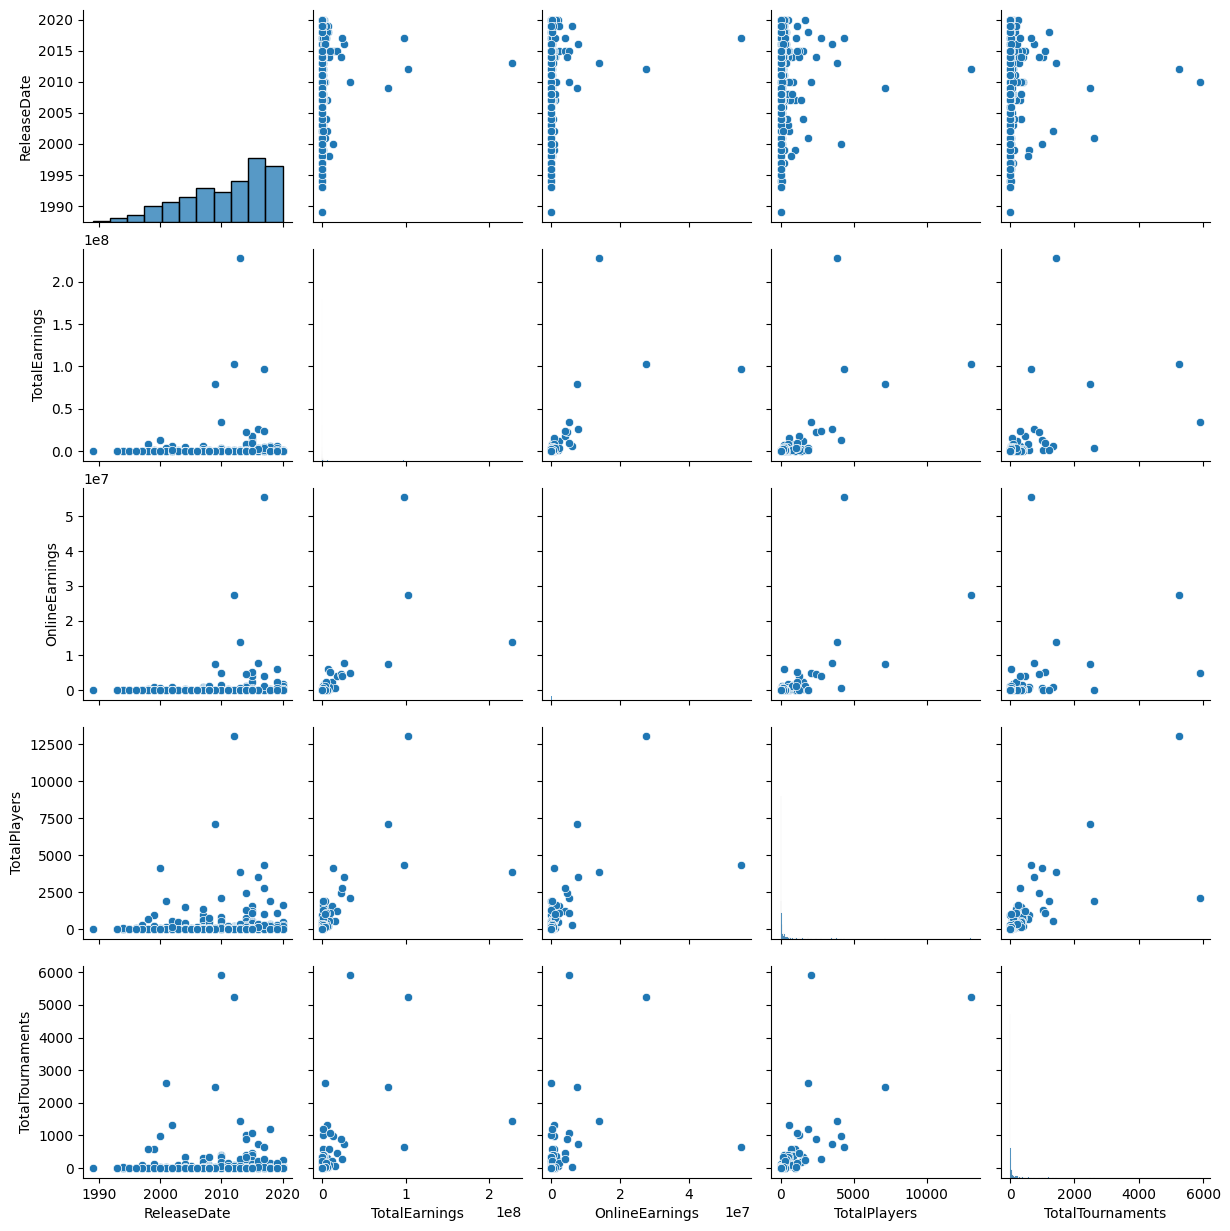

In [5]:
sns.pairplot(esports_data_filtered)

I see some correlation between total earnings and other variables, although definitely release date has little to no influence on this. This changes how I will make my causal diagram.

# Causal Diagram

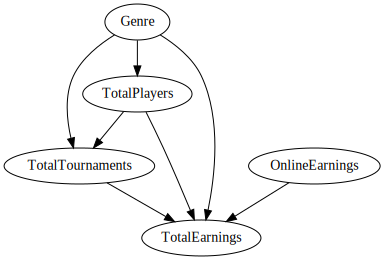

In [6]:
dag = gv.Digraph(comment='esports dag', format='png')

dag.node('Genre')
dag.node('TotalPlayers')
dag.node('TotalTournaments')
dag.node('OnlineEarnings')
dag.node('TotalEarnings')

dag.edge('Genre', 'TotalPlayers')
dag.edge('Genre', 'TotalTournaments')
dag.edge('TotalPlayers', 'TotalTournaments')
dag.edge('TotalTournaments', 'TotalEarnings')
dag.edge('OnlineEarnings', 'TotalEarnings')
dag.edge('TotalPlayers', 'TotalEarnings')
dag.edge('Genre', 'TotalEarnings')

dag

Everything here seems pretty intuitive, more players leads to more tournament opportunities, and genre may play a unprecedented role in the earnings of a game. This may exaggerate the importance of genres, but when it comes to a third person shooter game versus standard puzzle games, I think shooter games will simply make a lot more money off genre alone.

# Reference Model

First, in order to use gamma I had to make sure all values were strictly positive.

In [7]:
scaler = StandardScaler()
# Select numerical columns that are predictors for scaling
numerical_cols = ['OnlineEarnings', 'TotalPlayers', 'TotalTournaments']

esports_data_filtered_scaled = esports_data_filtered.copy()
esports_data_filtered_scaled[numerical_cols] = scaler.fit_transform(esports_data_filtered_scaled[numerical_cols])

esports_model = bmb.Model("TotalEarnings ~ poly(OnlineEarnings, degree=3) + TotalPlayers + TotalTournaments + Genre", esports_data_filtered_scaled, family="gamma", link="log")
idata_esports_model = esports_model.fit(draws=2000, chains=4, tune=3000, target_accept=0.99, init='auto', idata_kwargs={'log_likelihood': True}, progressbar=False)


Text(0, 0.5, 'TotalEarnings')

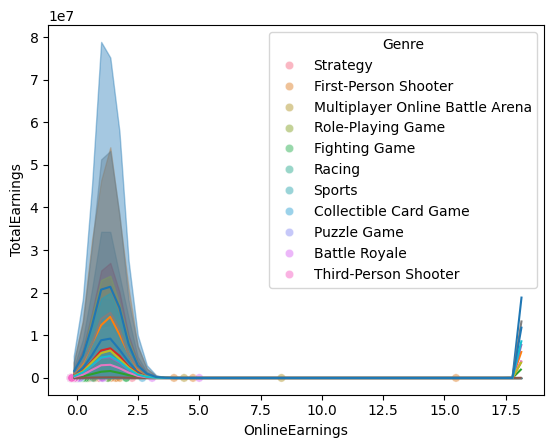

In [8]:
bmb.interpret.plot_predictions(
    esports_model,
    idata_esports_model,
    conditional=["OnlineEarnings", "Genre"],
    pps=True
)

sns.scatterplot(
    data=esports_data_filtered_scaled,
    x='TotalPlayers',
    y='TotalTournaments',
    hue='Genre',
    alpha=0.5,
    zorder=-3
)

plt.xlabel("OnlineEarnings")
plt.ylabel("TotalEarnings")

# Models

In [9]:
esports_model2 = bmb.Model("TotalEarnings ~ bs(OnlineEarnings, df=4, degree=3) + TotalPlayers + TotalTournaments + Genre", esports_data_filtered_scaled, family="gamma", link="log")
idata_esports_model2 = esports_model2.fit(draws=2000, chains=4, tune=3000, target_accept=0.99, init='auto', idata_kwargs={'log_likelihood': True}, progressbar=False)

Text(0, 0.5, 'TotalEarnings')

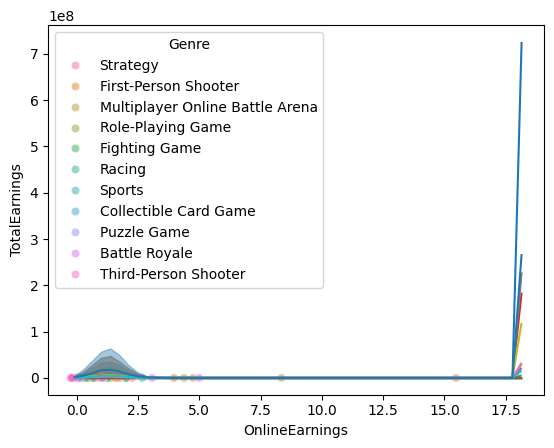

In [10]:
bmb.interpret.plot_predictions(
    esports_model2,
    idata_esports_model2,
    conditional=["OnlineEarnings", "Genre"],
    pps=True
)

sns.scatterplot(
    data=esports_data_filtered_scaled,
    x='TotalPlayers',
    y='TotalTournaments',
    hue='Genre',
    alpha=0.5,
    zorder=-3
)

plt.xlabel("OnlineEarnings")
plt.ylabel("TotalEarnings")

In [11]:
#ig stands for inverse gamma
def get_ig_params(x_vals, l_b=None, u_b=None, mass=0.96, plot=False):
    """
    Returns a weakly informative prior for the length-scale parameter of the GP kernel.
    """

    differences = np.abs(np.subtract.outer(x_vals, x_vals))
    if l_b is None:
        l_b = np.min(differences[differences != 0]) * 2
    if u_b is None:
        u_b = np.max(differences) / 1.5

    dist = pz.InverseGamma()
    pz.maxent(dist, l_b, u_b, mass, plot=plot)

    return dict(zip(dist.param_names, dist.params))

In [16]:
X_cont = esports_data_filtered_scaled[['OnlineEarnings', 'TotalPlayers', 'TotalTournaments']].values

# Factorize Genre to get integers
genre_idxs, genres = pd.factorize(esports_data_filtered['Genre'])
n_genres = len(genres)

with pm.Model() as esports_model_multivariate:
    ℓ = pm.InverseGamma('ℓ', alpha=3, beta=1, shape=3)
    cov = pm.gp.cov.ExpQuad(3, ls=ℓ)

    gp = pm.gp.HSGP(m=[5, 5, 5], c=8.0, cov_func=cov)
    f = gp.prior('f', X=X_cont)

    # Categorical part (Genre)
    # Individual intercept for each genre
    genre_offset = pm.Normal("genre_offset", mu=0, sigma=1, shape=n_genres)

    # Likelihood
    phi = pm.HalfNormal("phi", 5)

    # Combine GP function with the specific genre offset
    mu = pm.math.exp(f + genre_offset[genre_idxs])

    y = pm.Gamma("y",
                 alpha=phi,
                 beta=phi / mu,
                 observed=esports_data_filtered['TotalEarnings'].values)

    idata = pm.sample(draws=250, tune=250, target_accept=0.99, progressbar=False, posterior_predictive_kwargs={'samples': 500}, posterior_predictive=True)


ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [18]:
idata

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [19]:
print(idata.groups)

<bound method InferenceData.groups of Inference data with groups:
	> posterior
	> sample_stats
	> observed_data>


In [23]:
X_cont = esports_data_filtered_scaled[['OnlineEarnings', 'TotalPlayers', 'TotalTournaments']].values

# Factorize Genre to get integers
genre_idxs, genres = pd.factorize(esports_data_filtered['Genre'])
n_genres = len(genres)

with pm.Model() as esports_model_multivariate:
    ℓ = pm.InverseGamma('ℓ', alpha=3, beta=1, shape=3)
    cov = pm.gp.cov.ExpQuad(3, ls=ℓ)

    gp = pm.gp.HSGP(m=[5, 5, 5], c=8.0, cov_func=cov)
    f = gp.prior('f', X=X_cont)

    # Categorical part (Genre)
    # Individual intercept for each genre
    genre_offset = pm.Normal("genre_offset", mu=0, sigma=1, shape=n_genres)

    # Likelihood
    phi = pm.HalfNormal("phi", 5)

    # Combine GP function with the specific genre offset
    mu = pm.math.exp(f + genre_offset[genre_idxs])

    y = pm.Gamma("y",
                 alpha=phi,
                 beta=phi / mu,
                 observed=esports_data_filtered['TotalEarnings'].values)

    idata = pm.sample(draws=1000, tune=1000, target_accept=0.99, progressbar=False, posterior_predictive_kwargs={'samples': 500}, posterior_predictive=True)

In [24]:
az.plot_ppc(idata, data_pairs={"y": esports_data_filtered_scaled['TotalEarnings'].values})

sns.scatterplot(
    data=esports_data_filtered_scaled,
    x='TotalPlayers',
    y='TotalTournaments',
    hue='Genre',
    alpha=0.5,
    zorder=-3
)


TypeError: `data` argument must have the group "posterior_predictive" for ppcplot

Now I will move onto elpd_loo to compare

In [ ]:
model_dict = {
    "TotalEarnings ~ poly(OnlineEarnings, df=4, degree=3) + TotalPlayers + TotalTournaments + Genre": idata_esports_model,
    "TotalEarnings ~ bs(OnlineEarnings, df=4, degree=3) + TotalPlayers + TotalTournaments + Genre": idata_esports_model2
}

# Compare the models
compare_df = az.compare(model_dict)

# Plot the comparison
az.plot_compare(compare_df)

compare_df

In [26]:
with esports_model_multivariate:
    pm.compute_log_likelihood(idata)

Output()

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimat

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
"TotalEarnings ~ poly(OnlineEarnings, df=4, degree=3) + TotalPlayers + TotalTournaments + Genre",0,-5880.944612,24.093500,0.000000,0.684458,67.575602,0.000000,True,log
"TotalEarnings ~ bs(OnlineEarnings, df=4, degree=3) + TotalPlayers + TotalTournaments + Genre",1,-5881.144428,26.141255,0.199817,0.239875,66.942829,3.294214,True,log
Gaussian Process,2,-5933.725050,20.405236,52.780438,0.075667,64.971155,14.387339,True,log


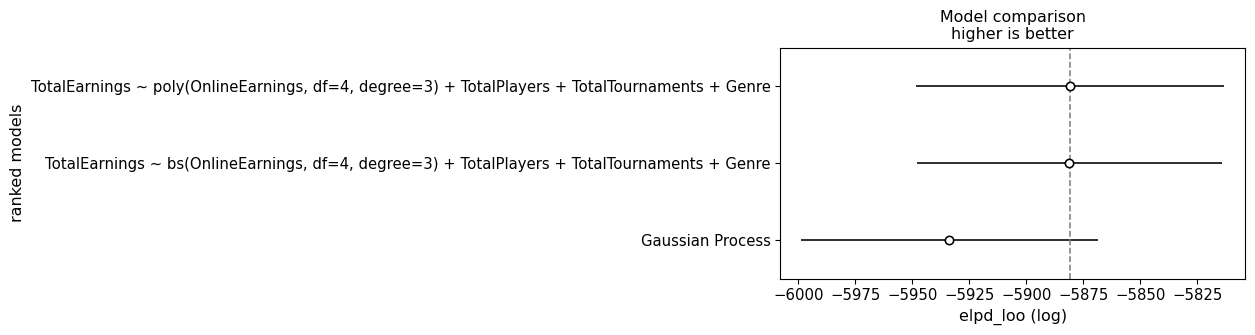

In [27]:
model_dict = {
    "TotalEarnings ~ poly(OnlineEarnings, df=4, degree=3) + TotalPlayers + TotalTournaments + Genre": idata_esports_model,
    "TotalEarnings ~ bs(OnlineEarnings, df=4, degree=3) + TotalPlayers + TotalTournaments + Genre": idata_esports_model2,
    "Gaussian Process": idata
}

# Compare the models
compare_df = az.compare(model_dict)

# Plot the comparison
az.plot_compare(compare_df)

compare_df

# Conclusion

Unfortunately I encountered a lot of issues trying to run my third model, it was taking multiple hours and I would have to stop in between. Even when I substantially lowered the draws there was still issues with az.plot_ppc that I couldn't end up fixing. This is a real bummer because I was the most confident in this one. I chose this final model because of the genre_offset that allows categorical difference handling. Gamma likelihood matches the skewed, strictly positive nature of the data.

I finally found a way to run the third model and had to compute the log likelihood.

Between the first two models, I noticed that the performances were very very similar. Therefore, I don't feel like it's right to say one performed better than the other. I don't exactly know how the reference model performed similarly to the b splines model, it may have been due to the nature of the data and lack of correlations.

The third model performed the worst, which I think is because the new complexities introduced new noise which ultimately led to a worse performance.